In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_visa_data.csv")

In [59]:
df.shape
df

,Applicant_Country,Visa_Type,Processing_Office,Application_Date,Decision_Date,Applicant_Age,Experience_Years,Processing_Time_Days
0,USA,Work,London,2022-03-19,2022-06-26,62,22.0,99
1,Germany,Work,Hyderabad,2022-09-03,2022-09-26,60,24.0,23
2,USA,Tourist,London,2022-03-25,2022-06-30,63,4.0,97
3,Canada,Tourist,Toronto,2022-12-21,2022-12-26,37,12.0,5
4,India,Tourist,New Delhi,2022-04-07,2022-06-12,26,13.0,66
5,Australia,Tourist,California,2022-09-06,2022-10-01,25,12.0,25
6,UK,Tourist,New Delhi,2022-11-20,2022-12-19,56,19.0,29
7,Canada,Tourist,Toronto,2022-03-14,2022-06-08,44,17.0,86
8,USA,Work,Hyderabad,2022-02-24,2022-03-17,29,3.0,21
9,Germany,Work,Hyderabad,2022-11-11,2023-03-05,29,12.0,114


In [60]:
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Applicant_Country     32 non-null     object 
 1   Visa_Type             32 non-null     object 
 2   Processing_Office     32 non-null     object 
 3   Application_Date      32 non-null     object 
 4   Decision_Date         32 non-null     object 
 5   Applicant_Age         32 non-null     int64  
 6   Experience_Years      32 non-null     float64
 7   Processing_Time_Days  32 non-null     int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 2.1+ KB


,Applicant_Country,Visa_Type,Processing_Office,Application_Date,Decision_Date,Applicant_Age,Experience_Years,Processing_Time_Days
0,USA,Work,London,2022-03-19,2022-06-26,62,22.0,99
1,Germany,Work,Hyderabad,2022-09-03,2022-09-26,60,24.0,23
2,USA,Tourist,London,2022-03-25,2022-06-30,63,4.0,97
3,Canada,Tourist,Toronto,2022-12-21,2022-12-26,37,12.0,5
4,India,Tourist,New Delhi,2022-04-07,2022-06-12,26,13.0,66
5,Australia,Tourist,California,2022-09-06,2022-10-01,25,12.0,25
6,UK,Tourist,New Delhi,2022-11-20,2022-12-19,56,19.0,29
7,Canada,Tourist,Toronto,2022-03-14,2022-06-08,44,17.0,86
8,USA,Work,Hyderabad,2022-02-24,2022-03-17,29,3.0,21
9,Germany,Work,Hyderabad,2022-11-11,2023-03-05,29,12.0,114


In [61]:
df.describe()
df

,Applicant_Country,Visa_Type,Processing_Office,Application_Date,Decision_Date,Applicant_Age,Experience_Years,Processing_Time_Days
0,USA,Work,London,2022-03-19,2022-06-26,62,22.0,99
1,Germany,Work,Hyderabad,2022-09-03,2022-09-26,60,24.0,23
2,USA,Tourist,London,2022-03-25,2022-06-30,63,4.0,97
3,Canada,Tourist,Toronto,2022-12-21,2022-12-26,37,12.0,5
4,India,Tourist,New Delhi,2022-04-07,2022-06-12,26,13.0,66
5,Australia,Tourist,California,2022-09-06,2022-10-01,25,12.0,25
6,UK,Tourist,New Delhi,2022-11-20,2022-12-19,56,19.0,29
7,Canada,Tourist,Toronto,2022-03-14,2022-06-08,44,17.0,86
8,USA,Work,Hyderabad,2022-02-24,2022-03-17,29,3.0,21
9,Germany,Work,Hyderabad,2022-11-11,2023-03-05,29,12.0,114


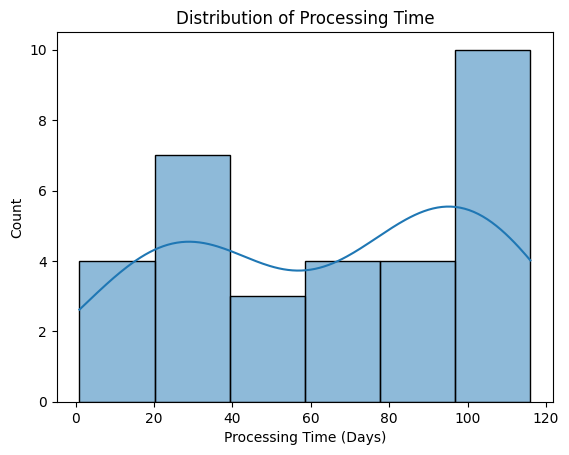

In [62]:
#Processing Time Distribution
plt.figure()
sns.histplot(df["Processing_Time_Days"], kde=True) # kde uses smooth density curve
plt.title("Distribution of Processing Time")
plt.xlabel("Processing Time (Days)")
plt.ylabel("Count")
plt.show()


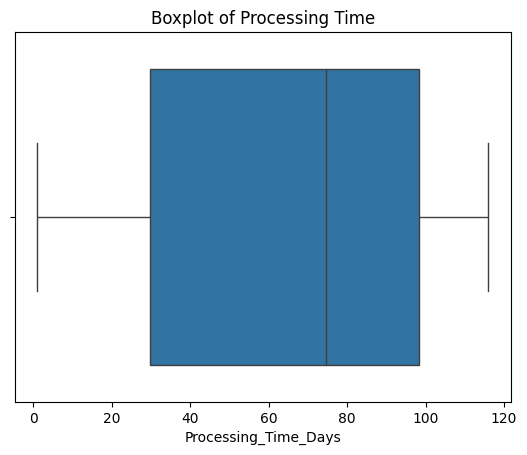

In [63]:
plt.figure()
sns.boxplot(x=df["Processing_Time_Days"]) # outlier detection- box plot
plt.title("Boxplot of Processing Time")
plt.show()

In [64]:
df["Application_Date"] = pd.to_datetime(df["Application_Date"])
df["application_month"] = df["Application_Date"].dt.month
# preparing the data for correlation
print(df)

   Applicant_Country Visa_Type Processing_Office Application_Date  \
0                USA      Work            London       2022-03-19   
1            Germany      Work         Hyderabad       2022-09-03   
2                USA   Tourist            London       2022-03-25   
3             Canada   Tourist           Toronto       2022-12-21   
4              India   Tourist         New Delhi       2022-04-07   
5          Australia   Tourist        California       2022-09-06   
6                 UK   Tourist         New Delhi       2022-11-20   
7             Canada   Tourist           Toronto       2022-03-14   
8                USA      Work         Hyderabad       2022-02-24   
9            Germany      Work         Hyderabad       2022-11-11   
10                UK      Work         Hyderabad       2022-05-04   
11            Canada      Work         New Delhi       2022-12-24   
12         Australia      Work        California       2022-12-11   
13               USA   Tourist    

In [65]:
corr_matrix = df[["Processing_Time_Days", "application_month"]].corr() # calculates the correlation values
print(corr_matrix)

# range: +1-> strong +ve relationship, 0-> no relationship, -1 -> strong -ve relationship


                      Processing_Time_Days  application_month
Processing_Time_Days              1.000000          -0.202218
application_month                -0.202218           1.000000


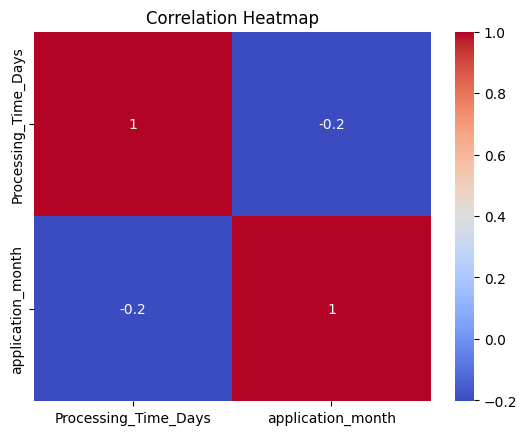

In [66]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm") # annot- shows nos inside the boxes, cmap- color scale for strnegth
plt.title("Correlation Heatmap")
plt.show()


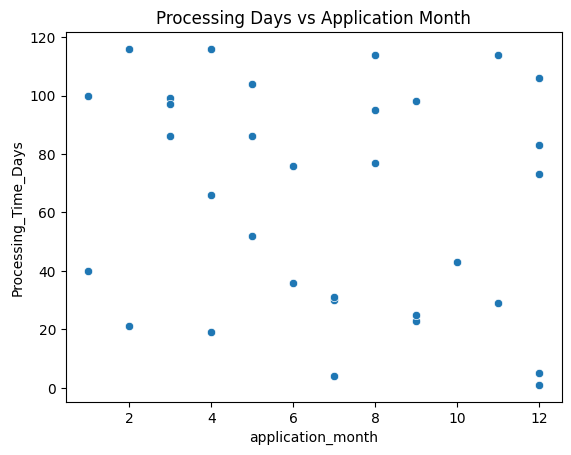

In [67]:
sns.scatterplot(
    x="application_month",
    y="Processing_Time_Days",
    data=df
)
plt.title("Processing Days vs Application Month")
plt.show()

In [68]:
print(df[["Application_Date", "application_month"]])

   Application_Date  application_month
0        2022-03-19                  3
1        2022-09-03                  9
2        2022-03-25                  3
3        2022-12-21                 12
4        2022-04-07                  4
5        2022-09-06                  9
6        2022-11-20                 11
7        2022-03-14                  3
8        2022-02-24                  2
9        2022-11-11                 11
10       2022-05-04                  5
11       2022-12-24                 12
12       2022-12-11                 12
13       2022-01-11                  1
14       2022-06-29                  6
15       2022-08-23                  8
16       2022-04-13                  4
17       2022-02-08                  2
18       2022-08-11                  8
19       2022-05-24                  5
20       2022-04-02                  4
21       2022-12-08                 12
22       2022-05-09                  5
23       2022-07-01                  7
24       2022-07-24      

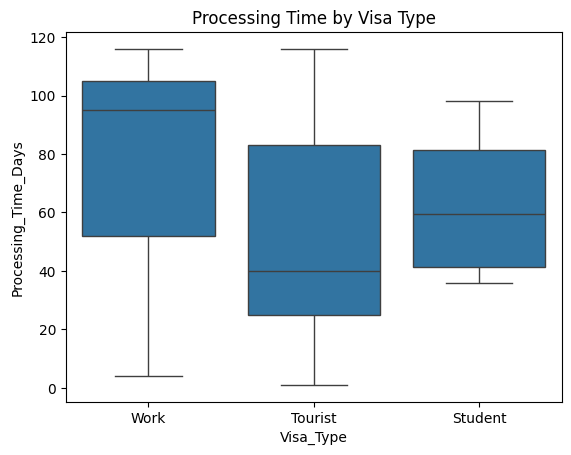

In [69]:
#Processing Time by Visa Type
plt.figure()
sns.boxplot(x="Visa_Type", y="Processing_Time_Days", data=df)
plt.title("Processing Time by Visa Type")
plt.show()

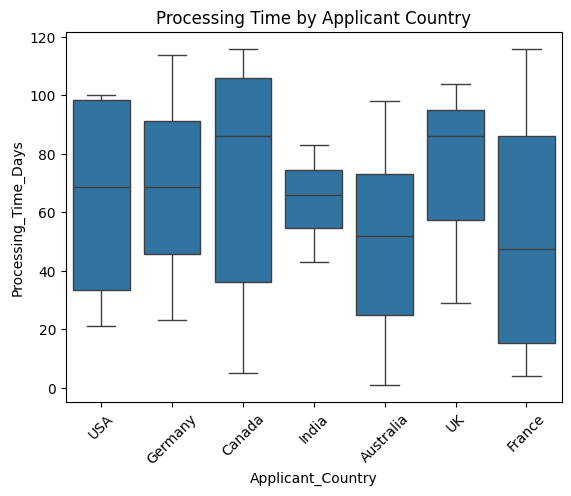

In [70]:
#Processing Time by Applicant Country
plt.figure()
sns.boxplot(x="Applicant_Country", y="Processing_Time_Days", data=df)
plt.xticks(rotation=45)
plt.title("Processing Time by Applicant Country")
plt.show()



Applications per Processing Office:
Processing_Office
London        6
Hyderabad     6
California    6
Toronto       5
New Delhi     5
Sydney        4
Name: count, dtype: int64


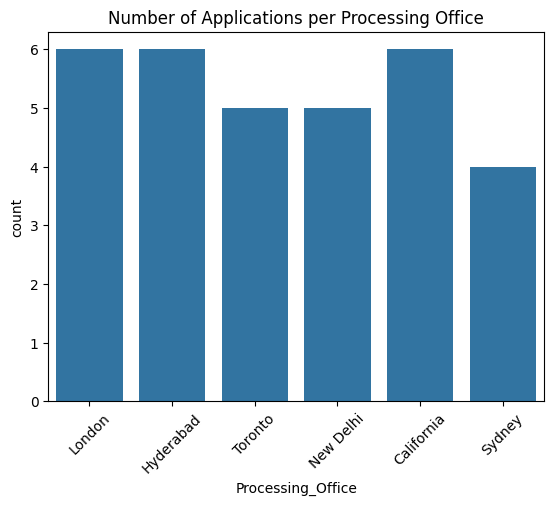

In [71]:
#Workload at Processing Centers
print("\nApplications per Processing Office:")
print(df["Processing_Office"].value_counts())

plt.figure()
sns.countplot(x="Processing_Office", data=df)
plt.xticks(rotation=45)
plt.title("Number of Applications per Processing Office")
plt.show()


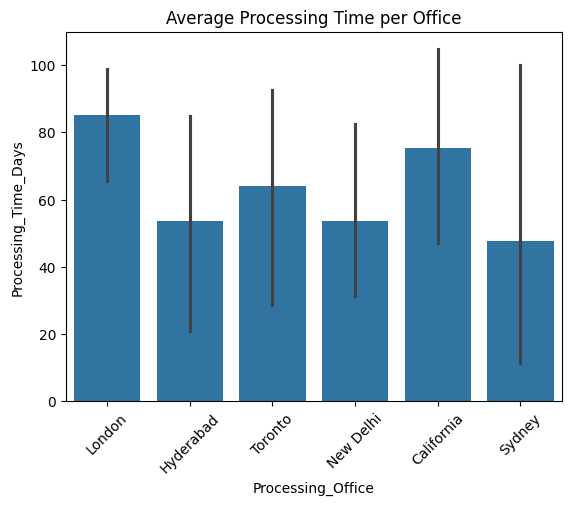

In [72]:
plt.figure()
sns.barplot(x="Processing_Office", y="Processing_Time_Days", data=df)
plt.xticks(rotation=45)
plt.title("Average Processing Time per Office")
plt.show()

In [73]:
#Seasonal Trend Analysis
df["season"]= df["application_month"].apply(
    lambda x: "Peak" if x in [1,2,12] else "off-peak"
) # runs the logic row by row

print(df[["application_month", "season"]])

    application_month    season
0                   3  off-peak
1                   9  off-peak
2                   3  off-peak
3                  12      Peak
4                   4  off-peak
5                   9  off-peak
6                  11  off-peak
7                   3  off-peak
8                   2      Peak
9                  11  off-peak
10                  5  off-peak
11                 12      Peak
12                 12      Peak
13                  1      Peak
14                  6  off-peak
15                  8  off-peak
16                  4  off-peak
17                  2      Peak
18                  8  off-peak
19                  5  off-peak
20                  4  off-peak
21                 12      Peak
22                  5  off-peak
23                  7  off-peak
24                  7  off-peak
25                  6  off-peak
26                 12      Peak
27                  8  off-peak
28                  7  off-peak
29                 10  off-peak
30      

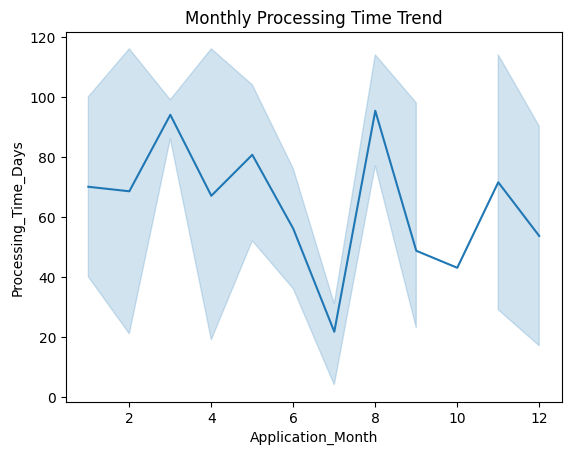

In [74]:
df["Application_Date"] = pd.to_datetime(df["Application_Date"])
df["Application_Month"] = df["Application_Date"].dt.month

plt.figure()
sns.lineplot(x="Application_Month", y="Processing_Time_Days", data=df)
plt.title("Monthly Processing Time Trend")
plt.show()

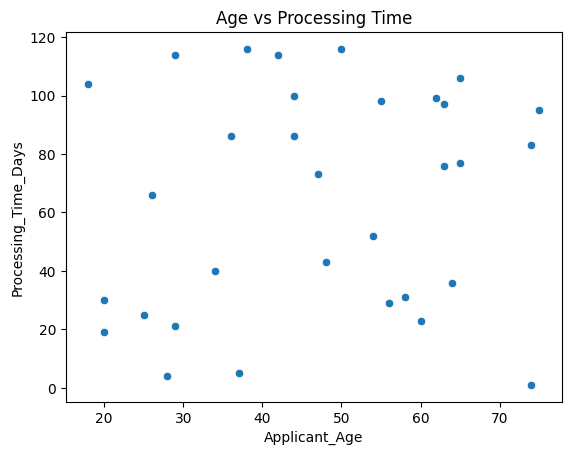

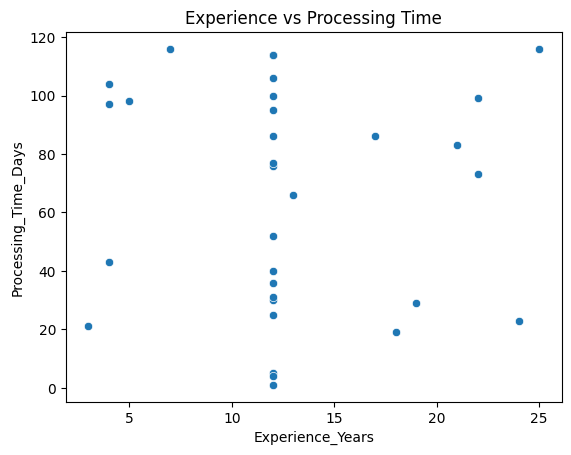

In [75]:
#Age & Experience Analysis
plt.figure()
sns.scatterplot(x="Applicant_Age", y="Processing_Time_Days", data=df)
plt.title("Age vs Processing Time")
plt.show()

plt.figure()
sns.scatterplot(x="Experience_Years", y="Processing_Time_Days", data=df)
plt.title("Experience vs Processing Time")
plt.show()

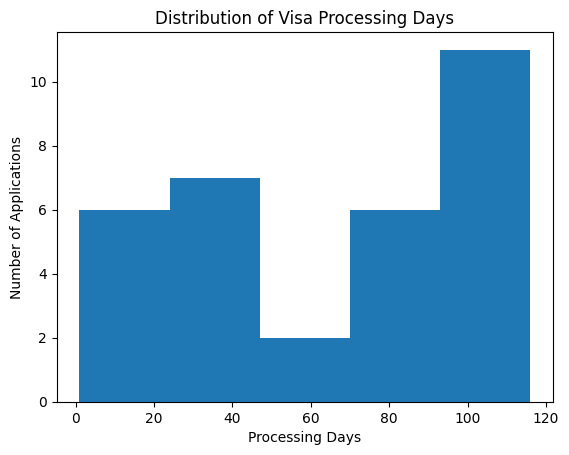

In [76]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["Processing_Time_Days"], bins=5)

plt.title("Distribution of Visa Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Number of Applications")

plt.show()

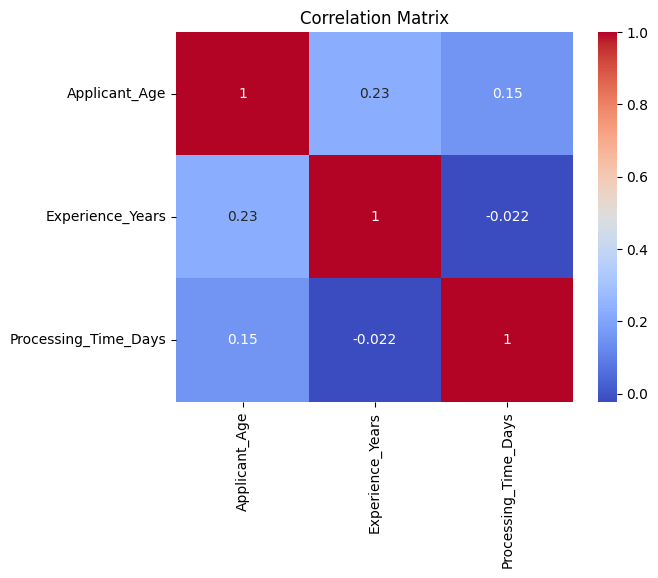


Milestone 2 EDA Completed Successfully.


In [77]:
plt.figure()
sns.heatmap(
    df[["Applicant_Age", "Experience_Years", "Processing_Time_Days"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

print("\nMilestone 2 EDA Completed Successfully.")
